# Original known-$R_p$ workflow: SciPy and Pyomo

This tutorial reuses the original LyoPRONTO vial, product, heat-transfer, pressure, and shelf-temperature case. The canonical computation lives in `examples.original_workflow_parity`; this notebook adds explanation and plots.

The legacy SciPy calculator integrates until the configured schedule ends or drying completes. The Pyomo model is a fixed-control validation replay on 26 backward-Euler intervals of 0.25 hr (6.5 hr total), with a terminal target of at least 95% dried. It is therefore a discretization comparison, not a replacement for event-terminated integration.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

repo_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from examples.original_workflow_parity import (
    KNOWN_RP_ENDPOINT_TOLERANCE_PP,
    pyomo_ipopt_status,
    run_known_rp_pyomo,
    run_known_rp_scipy,
)

The seven legacy columns are time [hr], sublimation-front temperature [degC], vial-bottom temperature [degC], shelf temperature [degC], chamber pressure [mTorr], sublimation flux [kg/hr/m$^2$], and percent dried [0-100].

In [2]:
scipy_output = run_known_rp_scipy(dt=0.25)
print(f"SciPy: {scipy_output.shape[0]} nodes, {scipy_output[-1, 0]:.2f} hr, {scipy_output[-1, 6]:.2f}% dried")

SciPy: 27 nodes, 6.50 hr, 97.75% dried


In [3]:
pyomo_ready, pyomo_message = pyomo_ipopt_status()
print(pyomo_message)
pyomo_result = run_known_rp_pyomo(scipy_output) if pyomo_ready else None
pyomo_output = pyomo_result.as_table() if pyomo_result is not None else None
if pyomo_result is not None:
    print(pyomo_result.message)
    print(f"Pyomo: {pyomo_output.shape[0]} nodes, {pyomo_output[-1, 0]:.2f} hr, {pyomo_output[-1, 6]:.2f}% dried")

Pyomo and IPOPT are available.


Pyomo trajectory solve reached optimal; maximum constraint violation 4.423e-08.
Pyomo: 27 nodes, 6.50 hr, 98.95% dried


In [4]:
display(Markdown(
    f"On the default grid the accepted endpoint tolerance is "
    f"**{KNOWN_RP_ENDPOINT_TOLERANCE_PP:g} percentage points dried**. "
    "This tolerance records first-order backward-Euler discretization error; "
    "pressure and shelf-temperature controls are fixed to the same sampled ramp profiles."
))

On the default grid the accepted endpoint tolerance is **1.5 percentage points dried**. This tolerance records first-order backward-Euler discretization error; pressure and shelf-temperature controls are fixed to the same sampled ramp profiles.

In [5]:
if pyomo_output is not None:
    endpoint_error = abs(pyomo_output[-1, 6] - scipy_output[-1, 6])
    assert pyomo_output.shape[1] == scipy_output.shape[1] == 7
    assert endpoint_error <= KNOWN_RP_ENDPOINT_TOLERANCE_PP
    print(f"Endpoint difference: {endpoint_error:.3f} percentage points dried")

Endpoint difference: 1.197 percentage points dried


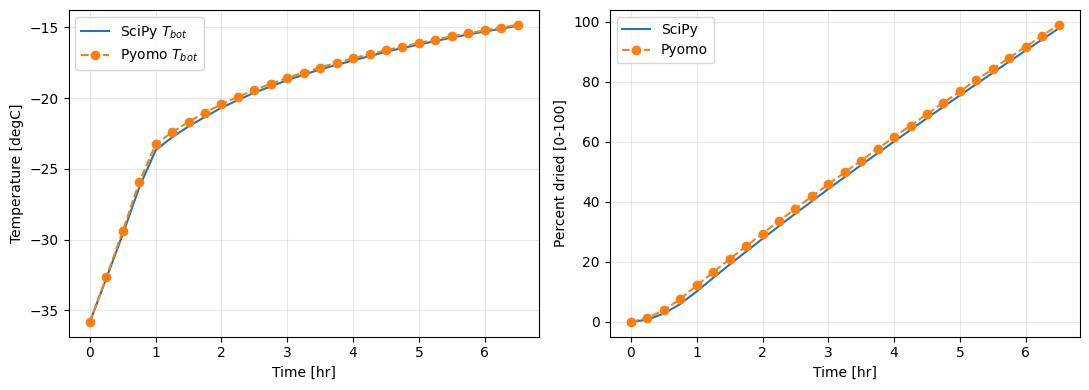

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(scipy_output[:, 0], scipy_output[:, 2], label="SciPy $T_{bot}$")
axes[1].plot(scipy_output[:, 0], scipy_output[:, 6], label="SciPy")
if pyomo_output is not None:
    axes[0].plot(pyomo_output[:, 0], pyomo_output[:, 2], "o--", label="Pyomo $T_{bot}$")
    axes[1].plot(pyomo_output[:, 0], pyomo_output[:, 6], "o--", label="Pyomo")
axes[0].set(xlabel="Time [hr]", ylabel="Temperature [degC]")
axes[1].set(xlabel="Time [hr]", ylabel="Percent dried [0-100]")
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
fig.tight_layout()